In [1]:
# =========================
# Core Python
# =========================
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# PyTorch
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm import tqdm
from transformers import CLIPModel
from torch.cuda.amp import autocast
from torch.amp import GradScaler   # new recommended API
# =========================
# Vision
# =========================
from PIL import Image
import torchvision.transforms as transforms

# =========================
# Audio
# =========================
import librosa

# =========================
# HuggingFace CLIP
# =========================
from transformers import CLIPModel, CLIPTokenizer

# =========================
# Evaluation
# =========================
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# =========================
# Utilities
# =========================
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# =========================
# Device
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# =========================
# Training settings
# =========================
BATCH_SIZE = 4        # safe for P100
NUM_EPOCHS = 10
LR = 1e-4

# =========================
# Video settings
# =========================
NUM_FRAMES = 16
IMG_SIZE = 224

# =========================
# CLIP settings
# =========================
MAX_TEXT_LEN = 77

# =========================
# Audio settings
# =========================
SR = 16000
N_MFCC = 40
MAX_AUDIO_LENGTH = 5  # seconds

# =========================
# Seed
# =========================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Configuration initialized")

Device: cuda
Configuration initialized


In [3]:
# =========================
# Dataset Root
# =========================
DATA_ROOT = Path("/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset")

# Frames
TRAIN_FRAMES = DATA_ROOT / "dataset_kaggle/extracted_frames/train"
TEST_FRAMES = DATA_ROOT / "dataset_kaggle/extracted_frames/test"

# Audio
TRAIN_AUDIO = DATA_ROOT / "extracted_audio/extracted_audio/train"
TEST_AUDIO = DATA_ROOT / "extracted_audio/extracted_audio/test"

# Metadata CSV
TRAIN_META = DATA_ROOT / "dataset_kaggle/extracted_text/train_metadata.csv"
TEST_META = DATA_ROOT / "dataset_kaggle/extracted_text/test_metadata.csv"

print("Dataset paths loaded")

Dataset paths loaded


In [4]:
# =========================
# Load metadata
# =========================
train_df = pd.read_csv(TRAIN_META)
test_df = pd.read_csv(TEST_META)

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

train_df.head()

Train samples: 1600
Test samples: 800


,video_id,has_audio,transcript,ocr_text,category,subcategory
0,IF_001,True,আপনি সিদ্ধান্ত নিয়েছেন একটি নতুন অ্যাপ্লিকেশন...,OR EVEN TAKA ON YOUR FIRST CRAZY TIME,misleading,identity_fabrication
1,IF_002,True,"With a small investment of 30,500 Bangladeshi ...",YES WITH A SMALL INVESTMENT OF BANGLADESH TAKA...,misleading,identity_fabrication
2,IF_003,True,"If they close this page, they can't come back ...",IF THEY CLOSE THIS PAGE AS WILL THEIR CHANCE T...,misleading,identity_fabrication
3,IF_004,True,We tested our product with a small group of vo...,AND EACH OF THEM EARNED OVER BANGLADESHI TAKA ...,misleading,identity_fabrication
4,IF_005,True,I am ready to give you your money back from my...,MONEY BACK FROM MY POCKET BANGLADESHI TAKA,misleading,identity_fabrication


In [5]:
# =========================
# Label mapping
# =========================
LABEL_MAP = {
    "safe": 0,
    "identity_fabrication": 1,
    "perception_manipulation": 2,
    "scientifically_unrealistic_scene": 3,
    "surreal_content": 4
}

ID2LABEL = {v:k for k,v in LABEL_MAP.items()}

NUM_CLASSES = len(LABEL_MAP)

print(LABEL_MAP)

{'safe': 0, 'identity_fabrication': 1, 'perception_manipulation': 2, 'scientifically_unrealistic_scene': 3, 'surreal_content': 4}


In [6]:
# =========================
# Frame transform
# =========================
frame_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    )
])

In [7]:
# =========================
# MFCC Feature Extraction
# =========================

def extract_mfcc(audio_path, sr=16000, n_mfcc=40, max_length=5):

    try:
        y, sr = librosa.load(audio_path, sr=sr)

        max_samples = sr * max_length

        if len(y) > max_samples:
            y = y[:max_samples]
        else:
            padding = max_samples - len(y)
            y = np.pad(y, (0, padding))

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=n_mfcc
        )

        return mfcc

    except:
        return np.zeros((n_mfcc, 160))

In [8]:
# =========================
# Format MFCC tensor
# =========================

def process_audio(audio_path):

    mfcc = extract_mfcc(audio_path)

    target_length = 160

    if mfcc.shape[1] > target_length:
        mfcc = mfcc[:, :target_length]

    elif mfcc.shape[1] < target_length:
        pad_width = target_length - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad_width)))

    mfcc = torch.tensor(mfcc, dtype=torch.float32)

    return mfcc

In [9]:
# =========================
# CLIP tokenizer
# =========================

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

print("Tokenizer loaded")

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Tokenizer loaded


In [10]:
# =========================
# Build label
# =========================

def get_label(row):

    if row["category"] == "safe":
        return LABEL_MAP["safe"]

    return LABEL_MAP[row["subcategory"]]

In [11]:
class MultimodalVideoDataset(Dataset):

    def __init__(self, df, frame_dir, audio_dir):

        self.df = df.reset_index(drop=True)
        self.frame_dir = frame_dir
        self.audio_dir = audio_dir


    def load_frames(self, video_id):

        video_path = self.frame_dir / video_id

        frames = []

        for i in range(1, NUM_FRAMES + 1):

            frame_path = video_path / f"frame_{i:02d}.jpg"

            if frame_path.exists():

                img = Image.open(frame_path).convert("RGB")
                img = frame_transform(img)

            else:

                img = torch.zeros(3,224,224)

            frames.append(img)

        frames = torch.stack(frames)

        return frames


    def load_audio(self, video_id, has_audio):

        if not has_audio:
            return torch.zeros(N_MFCC,160)

        audio_path = self.audio_dir / f"{video_id}.wav"

        if not audio_path.exists():
            return torch.zeros(N_MFCC,160)

        return process_audio(audio_path)


    def load_text(self, transcript, ocr):
        transcript = "" if pd.isna(transcript) else transcript
        ocr = "" if pd.isna(ocr) else ocr
    
        text = transcript + " " + ocr
    
        encoded = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )
    
        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
        }


    def __len__(self):
        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        video_id = row["video_id"]

        frames = self.load_frames(video_id)

        audio = self.load_audio(video_id, row["has_audio"])

        text = self.load_text(
            row["transcript"],
            row["ocr_text"]
        )

        label = get_label(row)

        return {
          "frames": frames,
          "audio": audio,
          "text_input_ids": text["input_ids"],
          "text_attention_mask": text["attention_mask"],
          "label": torch.tensor(label)
        }

In [12]:
train_dataset = MultimodalVideoDataset(
    train_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

test_dataset = MultimodalVideoDataset(
    test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

print("Datasets created")

Datasets created


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Dataloaders ready")

Dataloaders ready


In [14]:
sample = train_dataset[0]

print("Frames shape:", sample["frames"].shape)
print("Audio shape:", sample["audio"].shape)
# print("Text shape:", sample["text"].shape)
print("Label:", sample["label"])

Frames shape: torch.Size([16, 3, 224, 224])
Audio shape: torch.Size([40, 160])
Label: tensor(1)


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

# Freeze CLIP encoders to save memory
for p in clip.parameters():
    p.requires_grad = False

clip.eval()
print("CLIP loaded + frozen.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded + frozen.


In [16]:
def clip_vision_embed(pixel_values):
    """
    Always returns a TENSOR embedding, compatible across HF versions.
    pixel_values: (N,3,224,224)
    """
    outputs = clip.vision_model(pixel_values=pixel_values)

    if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        return outputs.pooler_output  # (N, D)

    return outputs.last_hidden_state.mean(dim=1)  # fallback (N, D)


def clip_text_embed(input_ids, attention_mask):
    """
    Always returns a TENSOR embedding, compatible across HF versions.
    input_ids: (B,77), attention_mask: (B,77)
    """
    outputs = clip.text_model(input_ids=input_ids, attention_mask=attention_mask)

    if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        return outputs.pooler_output  # (B, D)

    return outputs.last_hidden_state.mean(dim=1)  # fallback (B, D)

In [17]:
class AudioEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.fc = nn.Linear(64 * 4 * 4, out_dim)

    def forward(self, x):
        # x: (B, 40, 160)
        x = x.unsqueeze(1)            # (B,1,40,160)
        x = self.net(x)               # (B,64,4,4)
        x = x.view(x.size(0), -1)     # (B,1024)
        return self.fc(x)             # (B,128)

In [18]:
batch0 = next(iter(train_loader))

frames0 = batch0["frames"]                      # (B,16,3,224,224)
audio0  = batch0["audio"]                       # (B,40,160)
ids0    = batch0["text_input_ids"]              # (B,77)
mask0   = batch0["text_attention_mask"]         # (B,77)

B = frames0.size(0)

frames0_flat = frames0.view(-1, 3, 224, 224).to(device)  # (B*16,3,224,224)
audio0 = audio0.to(device)
ids0 = ids0.to(device)
mask0 = mask0.to(device)

audio_encoder0 = AudioEncoder(out_dim=128).to(device)
audio_encoder0.eval()

with torch.no_grad():
    img_feat0 = clip_vision_embed(frames0_flat)          # (B*16, Dimg)
    img_feat0 = img_feat0.view(B, 16, -1).mean(dim=1)    # (B, Dimg)

    txt_feat0 = clip_text_embed(ids0, mask0)             # (B, Dtxt)

    aud_feat0 = audio_encoder0(audio0)                   # (B, 128)

fusion_dim = img_feat0.shape[1] + txt_feat0.shape[1] + aud_feat0.shape[1]
print("Detected dims -> image:", img_feat0.shape[1], 
      "text:", txt_feat0.shape[1], 
      "audio:", aud_feat0.shape[1],
      "fusion:", fusion_dim)

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Detected dims -> image: 768 text: 512 audio: 128 fusion: 1408


In [19]:
class FusionClassifierVTA(nn.Module):
    def __init__(self, fusion_dim, num_classes=5, audio_out=128):
        super().__init__()
        self.audio_encoder = AudioEncoder(out_dim=audio_out)

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, frames, input_ids, attention_mask, audio):
        b = frames.size(0)

        # frames: (B,16,3,224,224)
        frames = frames.view(-1, 3, 224, 224).to(device)

        # audio: (B,40,160)
        audio = audio.to(device)

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        # frozen CLIP embeddings
        with torch.no_grad():
            img_feat = clip_vision_embed(frames)        # (B*16, Dimg)
        img_feat = img_feat.view(b, 16, -1).mean(dim=1) # (B, Dimg)

        with torch.no_grad():
            txt_feat = clip_text_embed(input_ids, attention_mask)  # (B, Dtxt)

        # trainable audio embedding
        aud_feat = self.audio_encoder(audio)            # (B, 128)

        fusion = torch.cat([img_feat, txt_feat, aud_feat], dim=1)  # (B, fusion_dim)

        return self.classifier(fusion)

In [20]:
model = FusionClassifierVTA(fusion_dim=fusion_dim, num_classes=5).to(device)
print("Fusion V+T+A model created.")

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    list(model.audio_encoder.parameters()) + list(model.classifier.parameters()),
    lr=1e-3
)

scaler = GradScaler("cuda")
print("Optimizer created. Trainable params:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

Fusion V+T+A model created.
Optimizer created. Trainable params: 878469


In [21]:
batch = next(iter(train_loader))
frames = batch["frames"]
audio  = batch["audio"]
ids    = batch["text_input_ids"]
mask   = batch["text_attention_mask"]

model.eval()
with torch.no_grad():
    out = model(frames, ids, mask, audio)

print(out.shape)  # expected: (BATCH_SIZE, 5)

torch.Size([4, 5])


In [22]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()   # Kaggle-safe

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader):
        frames = batch["frames"]
        audio  = batch["audio"]
        ids    = batch["text_input_ids"]
        mask   = batch["text_attention_mask"]
        labels = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast():   # ✅ no device_type here
            outputs = model(frames, ids, mask, audio)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 400/400 [03:33<00:00,  1.87it/s]


Epoch 1/5 Loss: 0.4408


100%|██████████| 400/400 [02:20<00:00,  2.84it/s]


Epoch 2/5 Loss: 0.1744


100%|██████████| 400/400 [02:21<00:00,  2.83it/s]


Epoch 3/5 Loss: 0.1210


100%|██████████| 400/400 [02:23<00:00,  2.80it/s]


Epoch 4/5 Loss: 0.1139


100%|██████████| 400/400 [02:30<00:00,  2.65it/s]

Epoch 5/5 Loss: 0.0692


In [23]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

@torch.no_grad()
def evaluate_vta(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    for batch in tqdm(loader):
        frames = batch["frames"]
        audio  = batch["audio"]
        ids    = batch["text_input_ids"]
        mask   = batch["text_attention_mask"]
        labels = batch["label"].to(device)

        logits = model(frames, ids, mask, audio)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    wf1 = f1_score(all_labels, all_preds, average="weighted")
    mf1 = f1_score(all_labels, all_preds, average="macro")

    return acc, wf1, mf1, all_labels, all_preds

In [24]:
acc, wf1, mf1, y_true, y_pred = evaluate_vta(model, test_loader)

print("Test Accuracy:", acc)
print("Test Weighted F1:", wf1)
print("Test Macro F1:", mf1)

label_names = ["safe", "identity_fabrication", "perception_manipulation",
               "scientifically_unrealistic_scene", "surreal_content"]

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

100%|██████████| 200/200 [01:37<00:00,  2.06it/s]

Test Accuracy: 0.735
Test Weighted F1: 0.7214885214163042
Test Macro F1: 0.6704255903100425

Classification Report:

                                  precision    recall  f1-score   support

                            safe     0.7196    0.9175    0.8066       400
            identity_fabrication     0.5890    0.4300    0.4971       100
         perception_manipulation     0.8136    0.4800    0.6038       100
scientifically_unrealistic_scene     0.7732    0.7500    0.7614       100
                 surreal_content     0.9016    0.5500    0.6832       100

                        accuracy                         0.7350       800
                       macro avg     0.7594    0.6255    0.6704       800
                    weighted avg     0.7445    0.7350    0.7215       800



In [25]:
import pandas as pd

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
cm_df

,safe,identity_fabrication,perception_manipulation,scientifically_unrealistic_scene,surreal_content
safe,367,8,3,16,6
identity_fabrication,55,43,2,0,0
perception_manipulation,36,15,48,1,0
scientifically_unrealistic_scene,14,5,6,75,0
surreal_content,38,2,0,5,55


In [26]:
def vision_features(frames):
    # frames: (B,16,3,224,224) on CPU
    b = frames.size(0)
    frames = frames.view(-1, 3, 224, 224).to(device)

    with torch.no_grad():
        img_feat = clip_vision_embed(frames)              # (B*16, Dimg)
    img_feat = img_feat.view(b, 16, -1).mean(dim=1)       # (B, Dimg)
    return img_feat


def text_features(input_ids, attention_mask):
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)

    with torch.no_grad():
        txt_feat = clip_text_embed(input_ids, attention_mask)  # (B, Dtxt)
    return txt_feat

In [27]:
@torch.no_grad()
def logits_vision_only(frames):
    # frames: (B,16,3,224,224)
    b = frames.size(0)
    frames = frames.view(-1, 3, 224, 224).to(device)
    img_feat = clip_vision_embed(frames)            # (B*16, D)
    img_feat = img_feat.view(b, 16, -1).mean(dim=1) # (B, D)

    # lightweight classifier head (we will define it below)
    return vision_head(img_feat)


@torch.no_grad()
def logits_text_only(input_ids, attention_mask):
    txt_feat = clip_text_embed(input_ids.to(device), attention_mask.to(device))
    return text_head(txt_feat)


@torch.no_grad()
def logits_vision_text(frames, input_ids, attention_mask):
    b = frames.size(0)
    frames = frames.view(-1, 3, 224, 224).to(device)

    img_feat = clip_vision_embed(frames)
    img_feat = img_feat.view(b, 16, -1).mean(dim=1)

    txt_feat = clip_text_embed(input_ids.to(device), attention_mask.to(device))

    fusion = torch.cat([img_feat, txt_feat], dim=1)
    return vt_head(fusion)

In [28]:
batch0 = next(iter(train_loader))
v0 = vision_features(batch0["frames"])
t0 = text_features(batch0["text_input_ids"], batch0["text_attention_mask"])

vision_dim = v0.shape[1]
text_dim = t0.shape[1]

print("vision_dim:", vision_dim, "text_dim:", text_dim)

vision_head = nn.Linear(vision_dim, 5).to(device)
text_head   = nn.Linear(text_dim, 5).to(device)
vt_head     = nn.Linear(vision_dim + text_dim, 5).to(device)

vision_dim: 768 text_dim: 512


In [29]:
from torch.cuda.amp import autocast, GradScaler

def train_head(head, mode="vision", epochs=2, lr=1e-3):
    head.train()
    opt = optim.Adam(head.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    scaler = GradScaler()

    for ep in range(epochs):
        total = 0.0
        for batch in tqdm(train_loader):
            labels = batch["label"].to(device)

            opt.zero_grad(set_to_none=True)

            # Extract frozen features (no grad) + train head (grad)
            if mode == "vision":
                feats = vision_features(batch["frames"])              # (B, Dv)
            elif mode == "text":
                feats = text_features(batch["text_input_ids"], batch["text_attention_mask"])  # (B, Dt)
            elif mode == "vt":
                v = vision_features(batch["frames"])
                t = text_features(batch["text_input_ids"], batch["text_attention_mask"])
                feats = torch.cat([v, t], dim=1)                      # (B, Dv+Dt)
            else:
                raise ValueError("Unknown mode")

            with autocast():
                logits = head(feats)   # <-- gradients flow here
                loss = loss_fn(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            total += loss.item()

        print(f"[{mode}] Epoch {ep+1}/{epochs} Loss: {total/len(train_loader):.4f}")

In [30]:
@torch.no_grad()
def eval_head(head=None, mode="vision"):
    all_preds, all_labels = [], []

    for batch in tqdm(test_loader):
        labels = batch["label"].to(device)

        if mode == "vision":
            feats = vision_features(batch["frames"])
            logits = head(feats)
        elif mode == "text":
            feats = text_features(batch["text_input_ids"], batch["text_attention_mask"])
            logits = head(feats)
        elif mode == "vt":
            v = vision_features(batch["frames"])
            t = text_features(batch["text_input_ids"], batch["text_attention_mask"])
            feats = torch.cat([v, t], dim=1)
            logits = head(feats)
        elif mode == "vta":
            logits = model(batch["frames"], batch["text_input_ids"], batch["text_attention_mask"], batch["audio"])
        else:
            raise ValueError("Unknown mode")

        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    wf1 = f1_score(all_labels, all_preds, average="weighted")
    mf1 = f1_score(all_labels, all_preds, average="macro")

    return acc, wf1, mf1

In [31]:
# Train heads
train_head(vision_head, mode="vision", epochs=2)
train_head(text_head, mode="text", epochs=2)
train_head(vt_head, mode="vt", epochs=2)

# Evaluate
results = {}
results["Vision only"] = eval_head(vision_head, "vision")
results["Text only"] = eval_head(text_head, "text")
results["Vision + Text"] = eval_head(vt_head, "vt")
results["Vision + Text + Audio"] = eval_head(None, "vta")

res_df = pd.DataFrame(results, index=["Accuracy", "Weighted F1", "Macro F1"]).T
res_df

100%|██████████| 400/400 [02:23<00:00,  2.79it/s]


[vision] Epoch 1/2 Loss: 0.5225


100%|██████████| 400/400 [02:06<00:00,  3.15it/s]


[vision] Epoch 2/2 Loss: 0.2592


100%|██████████| 400/400 [02:01<00:00,  3.29it/s]


...

[vt] Epoch 1/2 Loss: 0.4197


100%|██████████| 400/400 [02:00<00:00,  3.31it/s]


[vt] Epoch 2/2 Loss: 0.1352


100%|██████████| 200/200 [01:01<00:00,  3.23it/s]


,Accuracy,Weighted F1,Macro F1
Vision only,0.74000,0.731534,0.681308
Text only,0.68250,0.666885,0.579692
Vision + Text,0.74375,0.730609,0.665526
Vision + Text + Audio,0.73500,0.721489,0.670426


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

label_names = ["safe", "identity_fabrication", "perception_manipulation",
               "scientifically_unrealistic_scene", "surreal_content"]

def softmax_probs(logits):
    return F.softmax(logits, dim=-1).detach().cpu().numpy()

In [33]:
@torch.no_grad()
def explain_sample(model, sample, topk=3):
    model.eval()

    # Prepare tensors (add batch dim)
    frames = sample["frames"].unsqueeze(0)                     # (1,16,3,224,224)
    audio  = sample["audio"].unsqueeze(0)                      # (1,40,160)
    ids    = sample["text_input_ids"].unsqueeze(0)             # (1,77)
    mask   = sample["text_attention_mask"].unsqueeze(0)        # (1,77)

    # Full
    full_logits = model(frames, ids, mask, audio)
    full_probs = softmax_probs(full_logits)[0]
    pred_id = int(np.argmax(full_probs))
    pred_label = label_names[pred_id]
    pred_conf = float(full_probs[pred_id])

    # Ablations
    zeros_frames = torch.zeros_like(frames)
    zeros_audio  = torch.zeros_like(audio)
    zeros_ids    = torch.zeros_like(ids)       # token ids = 0
    zeros_mask   = torch.zeros_like(mask)      # no attention

    v_drop_logits = model(zeros_frames, ids, mask, audio)
    t_drop_logits = model(frames, zeros_ids, zeros_mask, audio)
    a_drop_logits = model(frames, ids, mask, zeros_audio)

    v_drop = softmax_probs(v_drop_logits)[0][pred_id]
    t_drop = softmax_probs(t_drop_logits)[0][pred_id]
    a_drop = softmax_probs(a_drop_logits)[0][pred_id]

    # contribution = how much confidence decreases when removed
    contrib = {
        "vision": max(0.0, pred_conf - float(v_drop)),
        "text":   max(0.0, pred_conf - float(t_drop)),
        "audio":  max(0.0, pred_conf - float(a_drop)),
    }

    # Normalize contributions for display (sum to 1)
    s = sum(contrib.values()) + 1e-9
    contrib_norm = {k: v/s for k,v in contrib.items()}

    # Top-k classes
    top_idx = np.argsort(full_probs)[::-1][:topk]
    top = [(label_names[i], float(full_probs[i])) for i in top_idx]

    return {
        "pred_id": pred_id,
        "pred_label": pred_label,
        "pred_conf": pred_conf,
        "top": top,
        "contrib_raw": contrib,
        "contrib_norm": contrib_norm
    }

In [34]:
@torch.no_grad()
def explain_sample(model, sample, topk=3):
    model.eval()

    # Prepare tensors (add batch dim)
    frames = sample["frames"].unsqueeze(0)                     # (1,16,3,224,224)
    audio  = sample["audio"].unsqueeze(0)                      # (1,40,160)
    ids    = sample["text_input_ids"].unsqueeze(0)             # (1,77)
    mask   = sample["text_attention_mask"].unsqueeze(0)        # (1,77)

    # Full
    full_logits = model(frames, ids, mask, audio)
    full_probs = softmax_probs(full_logits)[0]
    pred_id = int(np.argmax(full_probs))
    pred_label = label_names[pred_id]
    pred_conf = float(full_probs[pred_id])

    # Ablations
    zeros_frames = torch.zeros_like(frames)
    zeros_audio  = torch.zeros_like(audio)
    zeros_ids    = torch.zeros_like(ids)       # token ids = 0
    zeros_mask   = torch.zeros_like(mask)      # no attention

    v_drop_logits = model(zeros_frames, ids, mask, audio)
    t_drop_logits = model(frames, zeros_ids, zeros_mask, audio)
    a_drop_logits = model(frames, ids, mask, zeros_audio)

    v_drop = softmax_probs(v_drop_logits)[0][pred_id]
    t_drop = softmax_probs(t_drop_logits)[0][pred_id]
    a_drop = softmax_probs(a_drop_logits)[0][pred_id]

    # contribution = how much confidence decreases when removed
    contrib = {
        "vision": max(0.0, pred_conf - float(v_drop)),
        "text":   max(0.0, pred_conf - float(t_drop)),
        "audio":  max(0.0, pred_conf - float(a_drop)),
    }

    # Normalize contributions for display (sum to 1)
    s = sum(contrib.values()) + 1e-9
    contrib_norm = {k: v/s for k,v in contrib.items()}

    # Top-k classes
    top_idx = np.argsort(full_probs)[::-1][:topk]
    top = [(label_names[i], float(full_probs[i])) for i in top_idx]

    return {
        "pred_id": pred_id,
        "pred_label": pred_label,
        "pred_conf": pred_conf,
        "top": top,
        "contrib_raw": contrib,
        "contrib_norm": contrib_norm
    }

In [35]:
def make_one_sentence_explanation(sample, result):
    # Decide dominant modality
    contrib = result["contrib_norm"]
    dom = max(contrib, key=contrib.get)

    transcript = sample.get("transcript", "")
    ocr = sample.get("ocr_text", "")

    # pick evidence snippet
    evidence = ""
    if isinstance(ocr, str) and len(ocr.strip()) > 0:
        evidence = ocr.strip()[:120]
    elif isinstance(transcript, str) and len(transcript.strip()) > 0:
        evidence = transcript.strip()[:120]

    label = result["pred_label"]
    conf = result["pred_conf"]

    dom_map = {
        "vision": "visual cues in the frames",
        "text": "textual cues from transcript/OCR",
        "audio": "audio cues in the speech/background"
    }

    if evidence:
        return f"Predicted **{label}** (confidence {conf:.2f}) mainly due to {dom_map[dom]}, with evidence like: “{evidence}…”"
    else:
        return f"Predicted **{label}** (confidence {conf:.2f}) mainly due to {dom_map[dom]}."

In [36]:
import matplotlib.pyplot as plt
import torch

def show_frames_grid(frames_tensor, title="Frames"):
    # frames_tensor: (16,3,224,224)
    frames = frames_tensor.detach().cpu()
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle(title, fontsize=14)

    # UN-normalize CLIP normalization for display
    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3,1,1)
    std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3,1,1)

    for i, ax in enumerate(axes.flatten()):
        img = frames[i] * std + mean
        img = img.clamp(0,1).permute(1,2,0).numpy()
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{i+1}", fontsize=10)

    plt.tight_layout()
    plt.show()

Top predictions: [('safe', 1.0), ('scientifically_unrealistic_scene', 6.517838491149064e-10), ('identity_fabrication', 2.0532305022857855e-10)]
Contribution (normalized): {'vision': 0.002328698078150072, 'text': 0.997670709966234, 'audio': 0.0}

Predicted **safe** (confidence 1.00) mainly due to textual cues from transcript/OCR, with evidence like: “STAND UP FOR
WHAT'S RIGHT Festival Rangoli Festival Rangoli Festival Rangoli. Festival Rangoli. Festival Rangoli Festiva…”


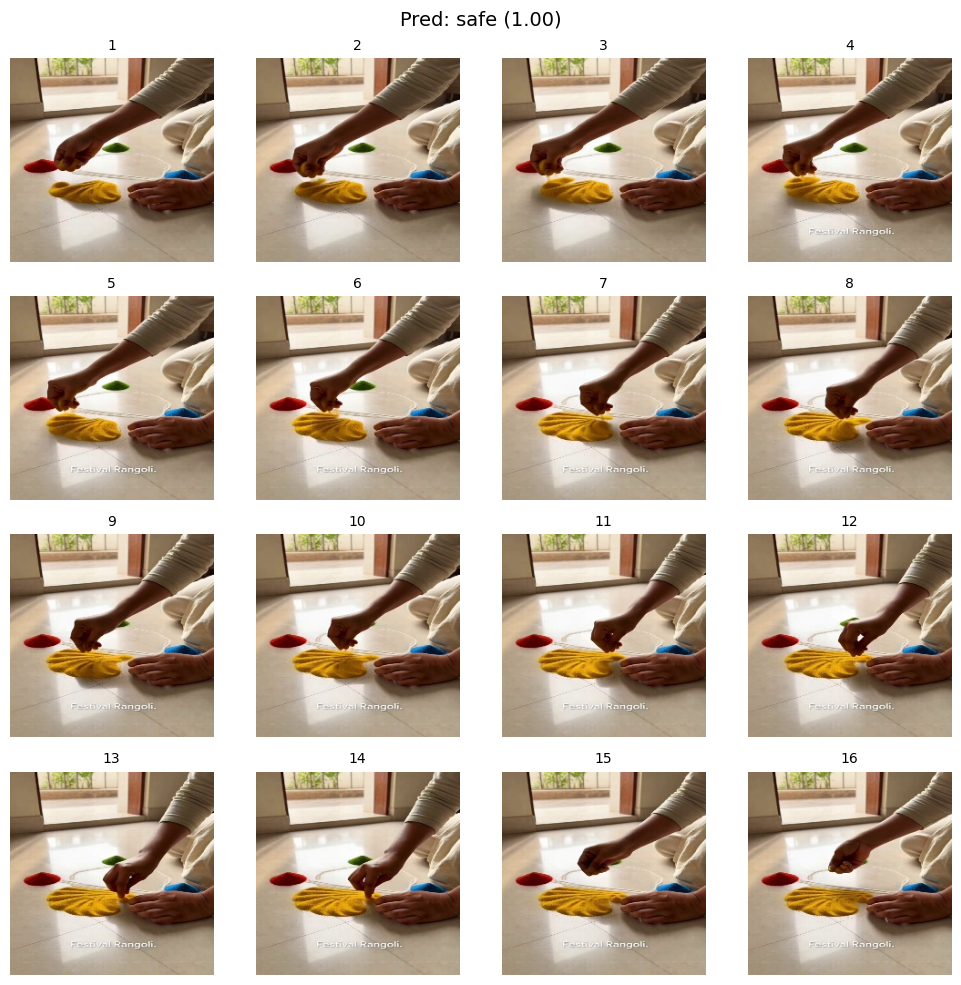

In [37]:
import random

idx = random.randint(0, len(test_dataset)-1)
sample = test_dataset[idx]

# attach raw text for explanation (optional but useful)
# If your dataset class doesn't store these, we can fetch from test_df by idx if needed.
sample["transcript"] = test_df.iloc[idx]["transcript"]
sample["ocr_text"] = test_df.iloc[idx]["ocr_text"]

result = explain_sample(model, sample, topk=3)

print("Top predictions:", result["top"])
print("Contribution (normalized):", result["contrib_norm"])
print()
print(make_one_sentence_explanation(sample, result))

show_frames_grid(sample["frames"], title=f"Pred: {result['pred_label']} ({result['pred_conf']:.2f})")

In [38]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def prob_for_class(model, frames, ids, mask, audio, class_id):
    logits = model(frames, ids, mask, audio)
    probs = F.softmax(logits, dim=-1)
    return float(probs[0, class_id].item())

In [39]:
@torch.no_grad()
def rank_frames(model, sample, pred_id):
    frames = sample["frames"].unsqueeze(0)   # (1,16,3,224,224)
    audio  = sample["audio"].unsqueeze(0)
    ids    = sample["text_input_ids"].unsqueeze(0)
    mask   = sample["text_attention_mask"].unsqueeze(0)

    base = prob_for_class(model, frames, ids, mask, audio, pred_id)

    drops = []
    for i in range(frames.size(1)):  # 16
        frames_abl = frames.clone()
        frames_abl[:, i] = 0.0  # remove frame i
        p = prob_for_class(model, frames_abl, ids, mask, audio, pred_id)
        drop = max(0.0, base - p)
        drops.append(drop)

    # rank desc
    order = np.argsort(drops)[::-1]
    return base, drops, order

In [40]:
import matplotlib.pyplot as plt
import torch

def show_frames_grid_with_ranks(frames_tensor, order, drops, topk=5, title="Top Frames"):
    frames = frames_tensor.detach().cpu()

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle(title, fontsize=14)

    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3,1,1)
    std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3,1,1)

    top_set = set(order[:topk].tolist())

    for i, ax in enumerate(axes.flatten()):
        img = frames[i] * std + mean
        img = img.clamp(0,1).permute(1,2,0).numpy()
        ax.imshow(img)
        ax.axis("off")

        if i in top_set:
            rank = np.where(order == i)[0][0] + 1
            ax.set_title(f"#{rank} (drop {drops[i]:.4f})", fontsize=10)
            # red border
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(3)
        else:
            ax.set_title(f"{i+1}", fontsize=10)

    plt.tight_layout()
    plt.show()

In [41]:
@torch.no_grad()
def text_source_influence(model, sample, pred_id, transcript, ocr):
    frames = sample["frames"].unsqueeze(0)
    audio  = sample["audio"].unsqueeze(0)

    # full text already exists in sample: ids/mask
    ids_full  = sample["text_input_ids"].unsqueeze(0)
    mask_full = sample["text_attention_mask"].unsqueeze(0)

    base = prob_for_class(model, frames, ids_full, mask_full, audio, pred_id)

    # transcript only
    enc_t = tokenizer(
        "" if transcript is None else str(transcript),
        padding="max_length",
        truncation=True,
        max_length=77,
        return_tensors="pt"
    )
    ids_t = enc_t["input_ids"]
    mask_t = enc_t["attention_mask"]

    # ocr only
    enc_o = tokenizer(
        "" if ocr is None else str(ocr),
        padding="max_length",
        truncation=True,
        max_length=77,
        return_tensors="pt"
    )
    ids_o = enc_o["input_ids"]
    mask_o = enc_o["attention_mask"]

    # prob when using transcript only / ocr only
    p_t = prob_for_class(model, frames, ids_t, mask_t, audio, pred_id)
    p_o = prob_for_class(model, frames, ids_o, mask_o, audio, pred_id)

    # Contribution = how much base confidence is supported by that source
    # (we can express as relative)
    return {
        "base": base,
        "p_transcript_only": p_t,
        "p_ocr_only": p_o
    }

In [42]:
@torch.no_grad()
def audio_chunk_influence(model, sample, pred_id, n_chunks=5):
    frames = sample["frames"].unsqueeze(0)
    ids    = sample["text_input_ids"].unsqueeze(0)
    mask   = sample["text_attention_mask"].unsqueeze(0)
    audio  = sample["audio"].unsqueeze(0)   # (1,40,160)

    base = prob_for_class(model, frames, ids, mask, audio, pred_id)

    T = audio.shape[-1]
    chunk_size = T // n_chunks

    drops = []
    for c in range(n_chunks):
        a = audio.clone()
        start = c * chunk_size
        end = (c+1) * chunk_size if c < n_chunks-1 else T
        a[:, :, start:end] = 0.0   # ablate chunk

        p = prob_for_class(model, frames, ids, mask, a, pred_id)
        drop = max(0.0, base - p)
        drops.append(drop)

    order = np.argsort(drops)[::-1]
    return base, drops, order

In [43]:
def full_explainability_report(model, dataset, df, idx, topk_frames=5, n_audio_chunks=5):
    sample = dataset[idx]

    # attach raw text sources from dataframe
    transcript = df.iloc[idx]["transcript"] if "transcript" in df.columns else ""
    ocr = df.iloc[idx]["ocr_text"] if "ocr_text" in df.columns else ""

    # full prediction
    with torch.no_grad():
        frames = sample["frames"].unsqueeze(0)
        audio  = sample["audio"].unsqueeze(0)
        ids    = sample["text_input_ids"].unsqueeze(0)
        mask   = sample["text_attention_mask"].unsqueeze(0)

        logits = model(frames, ids, mask, audio)
        probs = F.softmax(logits, dim=-1)[0].cpu().numpy()
        pred_id = int(np.argmax(probs))
        pred_label = label_names[pred_id]
        pred_conf = float(probs[pred_id])

    print("="*70)
    print(f"Index: {idx}")
    print(f"Prediction: {pred_label} | confidence: {pred_conf:.4f}")
    print("Top-3:", [(label_names[i], float(probs[i])) for i in np.argsort(probs)[::-1][:3]])
    print("="*70)

    # (1) Rank frames
    base_v, frame_drops, frame_order = rank_frames(model, sample, pred_id)
    print("\n[Frame importance - top ranked]")
    for r in range(topk_frames):
        f = int(frame_order[r])
        print(f"Rank #{r+1}: frame_{f+1:02d}  | drop={frame_drops[f]:.6f}")

    show_frames_grid_with_ranks(sample["frames"], frame_order, frame_drops,
                               topk=topk_frames,
                               title=f"Top Frames for {pred_label} ({pred_conf:.2f})")

    # (2) Text source
    text_info = text_source_influence(model, sample, pred_id, transcript, ocr)
    print("\n[Text influence]")
    print(f"Base prob: {text_info['base']:.6f}")
    print(f"Transcript-only prob: {text_info['p_transcript_only']:.6f}")
    print(f"OCR-only prob:        {text_info['p_ocr_only']:.6f}")

    # show snippets
    t_snip = str(transcript)[:200].replace("\n", " ")
    o_snip = str(ocr)[:200].replace("\n", " ")
    print("\nTranscript snippet:", t_snip)
    print("OCR snippet:", o_snip)

    # (3) Audio chunks
    base_a, aud_drops, aud_order = audio_chunk_influence(model, sample, pred_id, n_chunks=n_audio_chunks)
    print("\n[Audio chunk influence]")
    for r in range(n_audio_chunks):
        c = int(aud_order[r])
        print(f"Rank #{r+1}: chunk {c+1}/{n_audio_chunks} | drop={aud_drops[c]:.6f}")

    # simple bar plot
    plt.figure(figsize=(8,3))
    plt.bar([f"c{i+1}" for i in range(n_audio_chunks)], aud_drops)
    plt.title("Audio chunk drop (higher = more important)")
    plt.ylabel("Prob drop")
    plt.show()

    print("="*70)

Index: 114
Prediction: safe | confidence: 0.9978
Top-3: [('safe', 0.9978030323982239), ('identity_fabrication', 0.0021445027086883783), ('perception_manipulation', 4.319549407227896e-05)]

[Frame importance - top ranked]
Rank #1: frame_04  | drop=0.003031
Rank #2: frame_06  | drop=0.002974
Rank #3: frame_03  | drop=0.002788
Rank #4: frame_09  | drop=0.002718
Rank #5: frame_05  | drop=0.002714


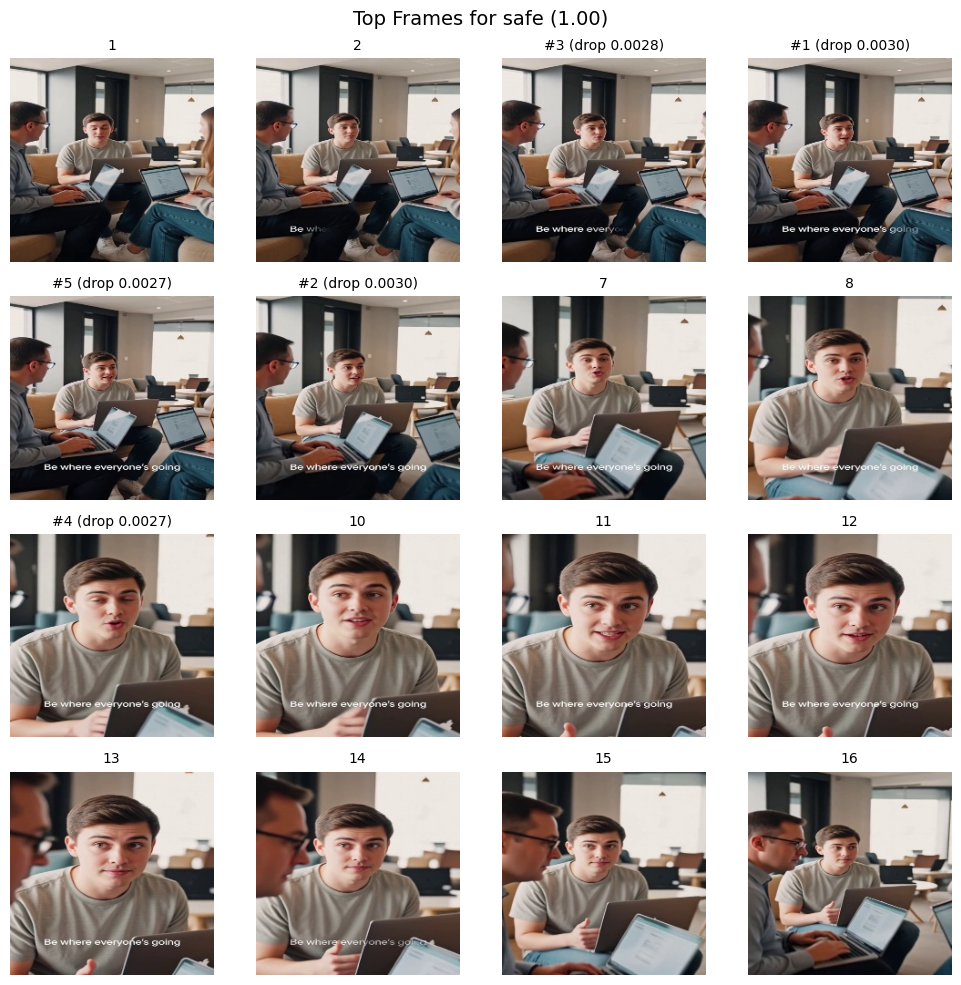


[Text influence]
Base prob: 0.997803
Transcript-only prob: 0.997803
OCR-only prob:        0.997918

Transcript snippet: This platform is becoming the standard, you should switch now to stay aligned.
OCR snippet: nan

[Audio chunk influence]
Rank #1: chunk 5/5 | drop=0.000050
Rank #2: chunk 2/5 | drop=0.000001
Rank #3: chunk 4/5 | drop=0.000000
Rank #4: chunk 3/5 | drop=0.000000
Rank #5: chunk 1/5 | drop=0.000000


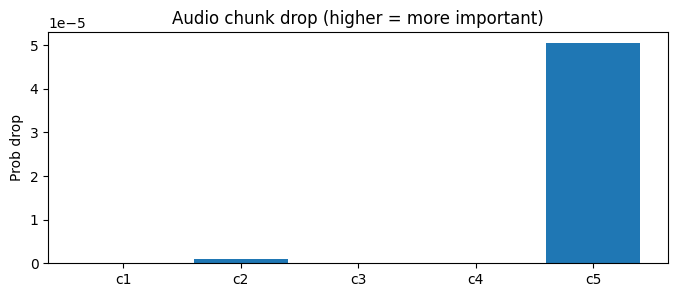

In [44]:
import random
idx = random.randint(0, len(test_dataset)-1)

full_explainability_report(model, test_dataset, test_df, idx,
                           topk_frames=5,
                           n_audio_chunks=5)